# Age Estimation
In this lab, we will implement our own designed Convolutional Neural Network(CNN).

First please download image dataset(APPA-REAL DATABASE) from http://chalearnlap.cvc.uab.es/dataset/26/data/45/description/, and unzip it. Copy this folder to DATASET. The files struction should looks like:

```
-----Network
    |
    |---- DATASET
    |    |-- appa-real-release
    |    |-- valid
    |    |-- feature_test.npy
    |    |-- feature_train.npy
    |    ...
    |---- helperP.pyc
    |---- helperT.pyc
    |---- ignore_list.csv
    |---- networkCustom.ipynb
    |---- pynetworkHidden.ipynb
           
           
           
```

In [26]:
import os
import numpy as np
from helperT import *

# Loading Data
At the heart of PyTorch data loading utility is the torch.utils.data.DataLoader class. It represents a Python iterable over a dataset. The function will return `train_loader`, `val_loader` and `test_loader` three data loaders. The training dataset has 3,995 labeled images, validation dataset has 1,500 labeled images, and testing dataset has 500 imgages, all of these are collected from APPA Dataset.

In the transform function, we will randomly add some Gaussian blur and noise, random flip, crop, rotate also added to traning and validation process. Don't worry, we have already integrated these for you. You can just using an python `enumerate` function to iterate those datasets.

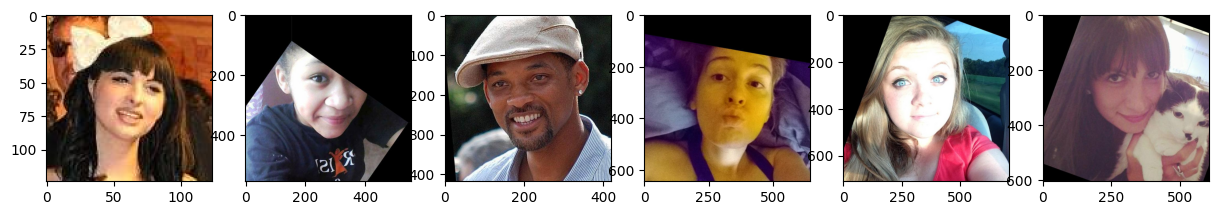

In [27]:
base_dir = 'DATASET/'
train_loader, val_loader, test_loader = get_img_dataloaders(base_dir)
show_data(base_dir)

# Network Structure
The torch.nn  module is the cornerstone of designing neural networks in PyTorch. This class can be used to implement a layer like a fully connected layer, a convolutional layer, a pooling layer, an activation function, and also an entire neural network by instantiating a torch.nn.Module object. 

The nn.Module class has two methods that you have to override.

- `__init__ `function. This function is invoked when you create an instance of the nn.Module. Here you will define the various parameters of a layer such as filters, kernel size for a convolutional layer, dropout probability for the dropout layer.
- `forward` function. This is where you define how your output is computed. This function doesn't need to be explicitly called, and can be run by just calling the nn.Module instance like a function with the input as it's argument.

Another widely used and important class is the nn.Sequential class.  When initiating this class we can pass a list of nn.Module objects in a particular sequence. The object returned by nn.Sequential is itself a nn.Module object. When this object is run with an input, it sequentially runs the input through all the nn.Module object we passed to it, in the very same order as we passed them.

After we defined our computing graph, we have to intitialize our networks's weights. You could try with Xavier initialization, or Kaiming initialization. If you want to get a better score in the end, adding batch normalization to the convolution layers is a good choice.

Here's some class or function might be useful for you:
- `nn.Conv2d()`
- `nn.MaxPool2d()`
- `nn.Sequential()`
- `nn.AdaptiveAvgPool2d()`
- `nn.Linear()`
- `nn.ReLU()`
- `nn.Dropout()`


Our CNN network designed as structure below:

| Layer name | kernel size | padding | activation | stride | (fan_in,fan_out) |
| ---------- | ----------- | ------- | ---------- | ------ | ---------------- |
| CONV64     | 7           | 3       | ReLU       |        |       (3,64)     |
| maxpool    | 2           |         |            | 2      |                  |
| CONV128-1  | 5           | 2       | ReLU       |        |     (64,128)     |
| CONV128-2  | 5           | 2       | ReLU       |        |    (128,128)     |
| maxpool    | 2           |         |            | 2      |                  |
| CONV256-1  | 3           | 1       | ReLU       |        |    (128,256)     |
| CONV256-2  | 3           | 1       | ReLU       |        |    (256,256)     |
| CONV256-3  | 3           | 1       | ReLU       |        |    (256,256)     |
| maxpool    | 2           |         |            | 2      |                  |
| CONV512-1  | 3           | 1       | ReLU       |        |    (256,512)     |
| CONV512-2  | 3           | 1       | ReLU       |        |    (512,512)     |
| CONV512-3  | 3           | 1       | ReLU       |        |    (512,512)     |
| maxpool    | 2           |         |            | 2      |                  |
| CONV512-4  | 3           | 1       | ReLU       |        |    (512,512)     |
| CONV512-5  | 3           | 1       | ReLU       |        |    (512,512)     |
| CONV512-6  | 3           | 1       | ReLU       |        |    (512,512)     |
| maxpool    | 2           |         |            | 2      |                  |
| FC1        |             |         | ReLU       |        |  (512x4x4,4096)  |
| FC2        |             |         | ReLU       |        |    (4096,4096)   |
| FC3        |             |         |            |        |    (4096,101)    |

In [28]:
'''
 INPUTS   ---------------->  128x128x64  ---------------->  64x64x64   
128x128x3     CONV-64              maxpool                       

  ---------------->  64x64x128   ---------------->  64x64x128  ---------------->  32x32x128
    CONV128-1             CONV128-2             maxpool
  
  ---------------->  32x32x256   ---------------->  32x32x256   ---------------->  32x32x256  ---------------->  16x16x256
    CONV256-1             CONV256-2             CONV256-3             maxpool
       
  ---------------->  16x16x512   ---------------->  16x16x512   ---------------->  16x16x512  ---------------->   8x8x512
    CONV512-1             CONV512-2             CONV512-3             maxpool

  ---------------->    8x8x512   ---------------->   8x8x512  ---------------->   8x8x512   ---------------->   4x4x512
    CONV512-4             CONV512-5             CONV512-6             maxpool
  
  4x4x512 ----------->  FC1  -----------> FC2  ----------->  FC3
              4096        4096          101

'''

'\n INPUTS   ---------------->  128x128x64  ---------------->  64x64x64   \n128x128x3     CONV-64              maxpool                       \n\n  ---------------->  64x64x128   ---------------->  64x64x128  ---------------->  32x32x128\n    CONV128-1             CONV128-2             maxpool\n  \n  ---------------->  32x32x256   ---------------->  32x32x256   ---------------->  32x32x256  ---------------->  16x16x256\n    CONV256-1             CONV256-2             CONV256-3             maxpool\n       \n  ---------------->  16x16x512   ---------------->  16x16x512   ---------------->  16x16x512  ---------------->   8x8x512\n    CONV512-1             CONV512-2             CONV512-3             maxpool\n\n  ---------------->    8x8x512   ---------------->   8x8x512  ---------------->   8x8x512   ---------------->   4x4x512\n    CONV512-4             CONV512-5             CONV512-6             maxpool\n  \n  4x4x512 ----------->  FC1  -----------> FC2  ----------->  FC3\n              4

In [29]:
class AgeNet(nn.Module):
    def __init__(self):
        super(AgeNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 * 4 * 4, 4096),
            nn.ReLU(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, 101),
        )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        output = self.classifier(x)
        return output

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

# Training and validation

In [30]:
def train_ageNet():

    # set the parameters for optimization (all should be kept same)
    EPOCH  = 100 #为方便调试，这里暂时设置为1，正式训练时设置为100即可
    TRAIN_LR = 0.001   #Learning rate
    MOMENTUM = 0.9    #SGD Momemutm

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AgeNet().to(device)
    print(model)

    optimizer = torch.optim.SGD(model.parameters(), lr=TRAIN_LR, momentum=MOMENTUM)
    criterion = nn.CrossEntropyLoss()
    ages = torch.arange(0, 101, dtype=torch.float32, device=device)
    best_model_path = "ageNet_best.pth"

    # Set the intial value for validation error
    loss_opt = 1e6
    best_predsVal = None
    best_gtsVal = None

    for e in range(EPOCH):
        # Training
        model.train()
        train_loss = 0.0
        train_count = 0

        for i, (y, x) in enumerate(train_loader):
            x = x.to(device).float()
            y = y.to(device).long()

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            train_count += x.size(0)

        # Validationu
        model.eval()
        gtsVal = []     # save all the ground truth for validation set (saved in numpy format)
        predsVal = []   # save all the  predictions for validation set (saved in numpy format)

        with torch.no_grad():
            for i, (y, x) in enumerate(val_loader):
                x = x.to(device).float()
                y = y.to(device).float()
                outputs = model(x)
                probs = F.softmax(outputs, dim=1)
                preds = (probs * ages).sum(dim=1)
                gtsVal.append(y.cpu().numpy())
                predsVal.append(preds.cpu().numpy())

        gtsVal = np.concatenate(gtsVal, axis=0)
        predsVal = np.concatenate(predsVal, axis=0)
        mae = np.mean(np.abs(predsVal - gtsVal))
        avg_train_loss = train_loss / train_count

        if(mae < loss_opt):
            loss_opt = mae
            best_predsVal = predsVal
            best_gtsVal = gtsVal
            torch.save(model, best_model_path)

        print("=> [epoch %.4d] mae validation: %.5f loss: %.3f" % (e + 1, mae, avg_train_loss))

    print("=> training finished")
    return best_predsVal, best_gtsVal

True
AgeNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): Conv2d(128, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (16): ReLU()
    (17): Conv2d(512, 512, kernel_size=(3, 3), stride=(

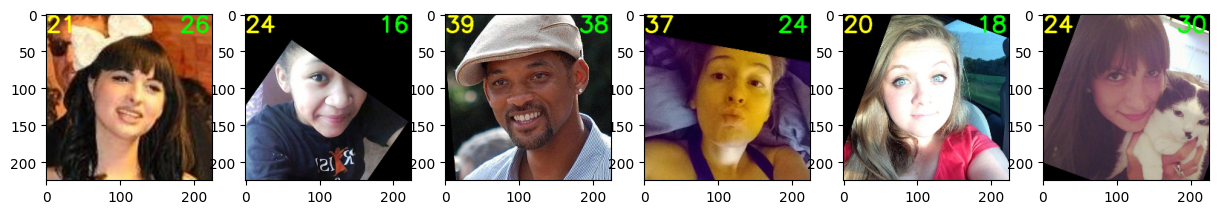

In [31]:
#if __name__ == "__main__":
print(torch.cuda.is_available())
preds, gt = train_ageNet()
show_results(preds, gt)

# Test and Generate results file

In [32]:
##########################################################################
# TODO: YOUR CODE HERE
########################################################################## 
# Load in the model saved in training process
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    model = torch.load("ageNet_best.pth", map_location=device, weights_only=False)
except TypeError:
    model = torch.load("ageNet_best.pth", map_location=device)
model = model.to(device)

# Do the test
prediction = test_cel(model, test_loader, "custom.txt")
print("Test results has saved to custom.txt")
print(prediction[:10])

Test results has saved to custom.txt
[19.92506518 58.38107668 35.45024984 22.84386949 27.70924543 38.67310557
 26.19817829 53.03760586 26.19723225 46.79528654]
